In [1]:
%load_ext autoreload

**** Start spectrum fitting via EM algorithm ****
background: none
<< Start fitting via Adapted EM Algorithm. >>
> iteration #  0, LL=-4.39044822e+13, residual=8.832e-01, elapsed time:  0.07 s
> iteration # 10, LL=-1.48620905e+13, residual=1.726e-04, elapsed time:  0.47 s
Convergence is achieved at iter.  19, elapsed time  0.93 s
   LogLikelihood:     -1.48601889e+13
        residual:      8.12875391e-08
<< Optimizing normalization factor by using least square method. >>
init 185917203701.26416
   non-linear least-square optimization is successfully finished.
            RMSE:      2.057111e+10
    Elapsed time:      3.082991e-03 s

Estimated model parameters and scores are following:
   x0:       -0.277 eV        0.482 eV        
   gamma:     1.324e+00          1.559e-01          
   eta:     9.900e-01          9.900e-01          
   N_tot:   1.860e+11 
   N:       9.122e+10       9.478e+10       
   pi:       4.904e-01       5.096e-01       
   LL:      -1.48601889e+13
   RMSE:     

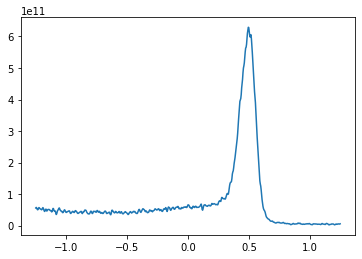

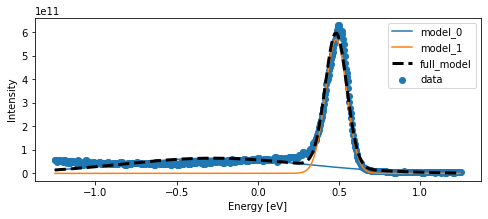

In [35]:
%autoreload 2

from EMPeaks import PseudoVoigtMixture, GaussianMixture, LorentzianMixture, DoniachSunjicMixture
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('/Users/yasunobu/Desktop/GFET0126_25V_C1s.txt')
x = (data.T[0] - np.average(data.T[0]))/10
y = (data.T[1] + 0.0002) * 10000000

plt.plot(x, y)

#model = GaussianMixture.GaussianMixtureModel(K=5, background='ramp_sum')
model = PseudoVoigtMixture.PseudoVoigtMixtureModel(K=2, background='none')
#model = LorentzianMixture.LorentzianMixtureModel(K=3, background='linear')
#model = DoniachSunjicMixture.DoniachSunjicMixtureModel(K=2, background='uniform')

#5回の初期パラメータサンプリングのあとに得られた最適なモデルをプロットします。
model.fit(x,y,r_eps=1e-7)
#model.sampling(x,y,r_eps=1e-7)
model.plot(x,y)